# Motor Insurance Claim Frequency Analysis

Exposure-adjusted claim frequency modelling using the freMTPL2 motor insurance dataset.

This analysis explores risk segmentation across driver age, vehicle age, and bonus-malus categories to identify key drivers of claim frequency.

## 1. Project Objective

The objective of this project is to analyse motor insurance claim frequency using exposure-adjusted methods and identify key risk factors influencing claim occurrence.

The analysis includes:
- Data exploration and cleaning
- Exposure-adjusted claim frequency calculation
- Risk segmentation
- Visual analysis of key risk drivers

## 2. Dataset Description

This project uses the **freMTPL2** motor insurance dataset, which contains policy-level information used for claim frequency analysis.

Key variables used in this project include:

- **ClaimNb**: Number of claims reported
- **Exposure**: Portion of the year for which the policy was active
- **DriverAge**: Age of the driver
- **VehAge**: Age of the vehicle
- **BonusMalus**: Policyholder bonus-malus level

Since policies may not all be active for the full year, claim frequency must be analysed using **exposure-adjusted methods**.

## 3. Data Loading

In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("../data/freMTPL2.csv")

# Preview dataset
df.head()

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1.0,1,0.10,D,5,0,55,50,B12,Regular,1217,R82
1,3.0,1,0.77,D,5,0,55,50,B12,Regular,1217,R82
2,5.0,1,0.75,B,6,2,52,50,B12,Diesel,54,R22
3,10.0,1,0.09,B,7,0,46,50,B12,Diesel,76,R72
4,11.0,1,0.84,B,7,0,46,50,B12,Diesel,76,R72


In [3]:
df.shape

(678013, 12)

## Data Quality & Preprocessing

Before conducting claim frequency analysis, the dataset was reviewed for structural issues such as missing values, duplicate records, invalid ranges, and variable types. Since insurance claim frequency modelling depends on both claim counts and exposure, it is important to confirm that the dataset is internally consistent before performing segmentation and regression analysis.

In [4]:
# Data quality checks

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nSummary statistics:")
display(df.describe(include='all'))

# Basic range checks for key variables
print("\nInvalid value checks:")
print("Negative ClaimNb:", (df['ClaimNb'] < 0).sum())
print("Non-positive Exposure:", (df['Exposure'] <= 0).sum())
print("Negative BonusMalus:", (df['BonusMalus'] < 0).sum())
print("Negative VehAge:", (df['VehAge'] < 0).sum())
print("Negative DrivAge:", (df['DrivAge'] < 0).sum())
print("Negative Density:", (df['Density'] < 0).sum())

Dataset shape: (678013, 12)

Column names:
['IDpol', 'ClaimNb', 'Exposure', 'Area', 'VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'VehBrand', 'VehGas', 'Density', 'Region']

Data types:
IDpol         float64
ClaimNb         int64
Exposure      float64
Area              str
VehPower        int64
VehAge          int64
DrivAge         int64
BonusMalus      int64
VehBrand          str
VehGas            str
Density         int64
Region            str
dtype: object

Missing values:
IDpol         0
ClaimNb       0
Exposure      0
Area          0
VehPower      0
VehAge        0
DrivAge       0
BonusMalus    0
VehBrand      0
VehGas        0
Density       0
Region        0
dtype: int64

Duplicate rows: 0

Summary statistics:


,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
count,6.780130e+05,678013.000000,678013.000000,678013,678013.000000,678013.000000,678013.000000,678013.000000,678013,678013,678013.000000,678013
unique,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN,11,2,NaN,22
top,NaN,NaN,NaN,C,NaN,NaN,NaN,NaN,B12,Regular,NaN,R24
freq,NaN,NaN,NaN,191880,NaN,NaN,NaN,NaN,166024,345877,NaN,160601
mean,2.621857e+06,0.053247,0.528750,NaN,6.454631,7.044265,45.499122,59.761502,NaN,NaN,1792.422405,NaN
std,1.641783e+06,0.240117,0.364442,NaN,2.050906,5.666232,14.137444,15.636658,NaN,NaN,3958.646564,NaN
min,1.000000e+00,0.000000,0.002732,NaN,4.000000,0.000000,18.000000,50.000000,NaN,NaN,1.000000,NaN
25%,1.157951e+06,0.000000,0.180000,NaN,5.000000,2.000000,34.000000,50.000000,NaN,NaN,92.000000,NaN
50%,2.272152e+06,0.000000,0.490000,NaN,6.000000,6.000000,44.000000,50.000000,NaN,NaN,393.000000,NaN
75%,4.046274e+06,0.000000,0.990000,NaN,7.000000,11.000000,55.000000,64.000000,NaN,NaN,1658.000000,NaN



Invalid value checks:
Negative ClaimNb: 0
Non-positive Exposure: 0
Negative BonusMalus: 0
Negative VehAge: 0
Negative DrivAge: 0
Negative Density: 0


### Data Quality Summary

The dataset does not show major structural issues that would prevent frequency analysis. Missing values and duplicate rows were checked, and key variables such as claim count, exposure, driver age, vehicle age, bonus-malus, and density were reviewed for invalid values. This step is important because unreliable exposure or claim count values can distort claim frequency estimates and model interpretation.

## 4. Claim Count Distribution

Before analysing claim frequency across different risk segments, it is useful to first examine the distribution of claim counts in the portfolio.

This helps in understanding whether claims are concentrated among a small number of policies and whether the target variable is skewed, which is common in motor insurance data.


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns


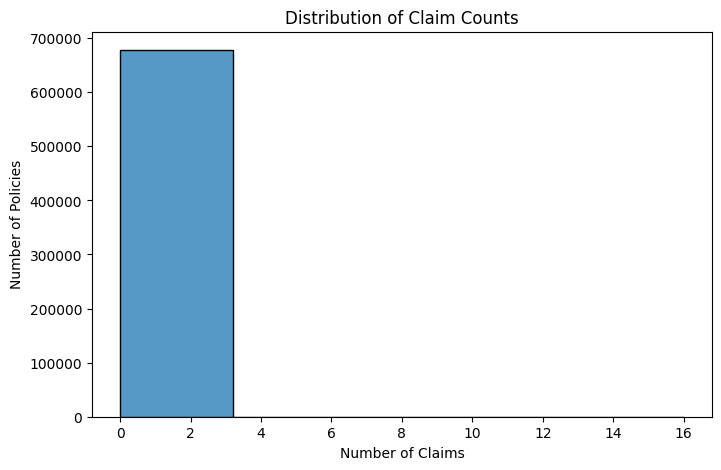

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["ClaimNb"], bins=5)

plt.title("Distribution of Claim Counts")
plt.xlabel("Number of Claims")
plt.ylabel("Number of Policies")

plt.savefig("../visuals/claim_count_distribution.png")
plt.show()


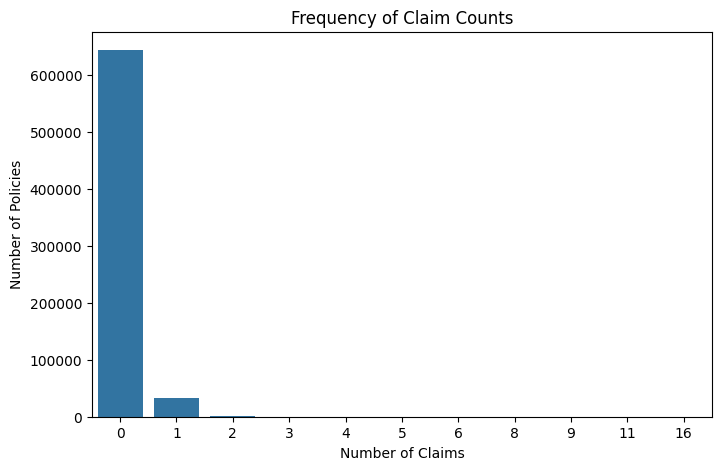

In [7]:
claim_counts = df["ClaimNb"].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=claim_counts.index, y=claim_counts.values)

plt.title("Frequency of Claim Counts")
plt.xlabel("Number of Claims")
plt.ylabel("Number of Policies")

plt.savefig("../visuals/claim_count_frequency.png")

plt.show()


In [38]:
# Claim count distribution (detailed)

claim_counts = df['ClaimNb'].value_counts().sort_index()

print("Claim count distribution:\n")
print(claim_counts.head(10))

# Proportion of zero claims
zero_claims = (df['ClaimNb'] == 0).mean()
print("\nProportion of zero-claim policies:", round(zero_claims, 4))

# Mean and variance
mean_claims = df['ClaimNb'].mean()
variance_claims = df['ClaimNb'].var()

print("\nMean of ClaimNb:", round(mean_claims, 4))
print("Variance of ClaimNb:", round(variance_claims, 4))

Claim count distribution:

ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
8          1
9          1
11         3
Name: count, dtype: int64

Proportion of zero-claim policies: 0.9498

Mean of ClaimNb: 0.0532
Variance of ClaimNb: 0.0577


### Key Observations

The claim count distribution is highly skewed, with a large proportion of policies having zero claims. This is typical in motor insurance datasets, where claims are relatively rare events.

The proportion of zero-claim policies is very high, indicating that most policyholders do not file claims within the exposure period.

Additionally, the variance of claim counts exceeds the mean, suggesting the presence of overdispersion. This is an important observation because it indicates that a simple Poisson model may not fully capture the variability in the data, motivating the need for further model diagnostics and alternative models such as the Negative Binomial.

Overall, the distribution confirms that claim frequency modelling should be approached using count-based statistical models with careful handling of excess zeros and variability.

## 5. Portfolio Claim Frequency

Claim frequency measures the expected number of claims per unit of exposure.

Since policies may not all be active for a full year, exposure-adjusted frequency is used to obtain an unbiased estimate of claim occurrence.

In [8]:
total_claims = df["ClaimNb"].sum()
total_exposure = df["Exposure"].sum()

claim_frequency = total_claims / total_exposure

print("Total Claims:", total_claims)
print("Total Exposure:", total_exposure)
print("Portfolio Claim Frequency:", round(claim_frequency,4))

Total Claims: 36102
Total Exposure: 358499.44546217704
Portfolio Claim Frequency: 0.1007


The overall portfolio claim frequency is **0.1007 claims per policy-year**. 

This indicates that, on average, approximately **10 claims occur for every 100 insured policies per year**. This metric provides a baseline risk level for the portfolio before performing further segmentation by risk characteristics.

## 6. Claim Frequency by Driver Age

Driver age is a key risk factor in motor insurance. Younger drivers often exhibit higher claim frequencies due to lower driving experience, while older drivers may show different risk patterns.

This section analyses claim frequency across driver age bands.

In [9]:
df["DriverAgeBand"] = pd.cut(
    df["DrivAge"],
    bins=[18,25,35,50,70,np.inf],
    labels=["18-25","26-35","36-50","51-70","70+"],
    include_lowest=True
)

In [39]:
age_risk = df.groupby("DriverAgeBand", observed=False).agg(
    Total_Claims=("ClaimNb", "sum"),
    Total_Exposure=("Exposure", "sum")
).reset_index()

age_risk["Claim_Frequency"] = age_risk["Total_Claims"] / age_risk["Total_Exposure"]

age_risk

,DriverAgeBand,Total_Claims,Total_Exposure,Claim_Frequency
0,18-25,2841,16227.903263,0.175069
1,26-35,6662,69266.778075,0.096179
2,36-50,13118,131989.064957,0.099387
3,51-70,10858,114060.324541,0.095195
4,70+,2623,26955.374625,0.097309


In [40]:
age_risk.sort_values(by="Total_Exposure", ascending=False)

,DriverAgeBand,Total_Claims,Total_Exposure,Claim_Frequency
2,36-50,13118,131989.064957,0.099387
3,51-70,10858,114060.324541,0.095195
1,26-35,6662,69266.778075,0.096179
4,70+,2623,26955.374625,0.097309
0,18-25,2841,16227.903263,0.175069


### Interpretation

The analysis shows that drivers aged **18–25 exhibit the highest claim frequency (0.173)** within the portfolio.

This frequency is substantially higher than other age groups, which have frequencies close to **0.095–0.099**.

The elevated claim frequency among younger drivers is consistent with insurance risk patterns, as younger drivers generally have less driving experience and a higher likelihood of accidents.

This segmentation highlights the importance of driver age as a key rating factor in motor insurance pricing.

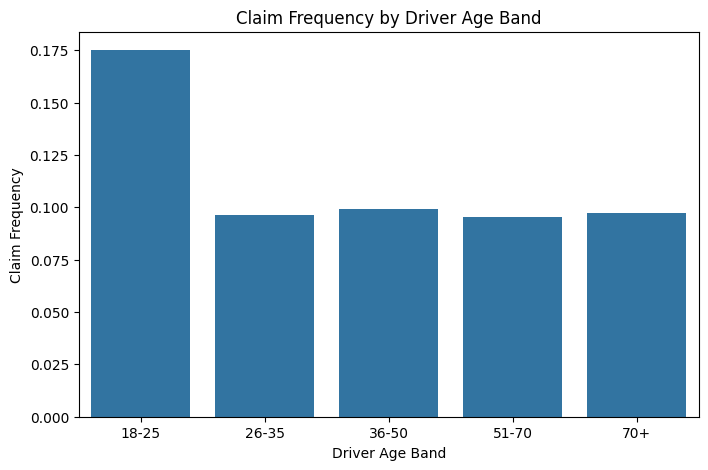

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    x=age_risk["DriverAgeBand"],
    y=age_risk["Claim_Frequency"]
)

plt.title("Claim Frequency by Driver Age Band")
plt.xlabel("Driver Age Band")
plt.ylabel("Claim Frequency")

plt.savefig("../visuals/driver_age_risk.png")

plt.show()

### Interpretation

Driver age bands show meaningful differences in claim frequency, with the 18–25 segment exhibiting the highest observed claim frequency in the portfolio.

However, these results should be interpreted together with exposure. Bands with larger total exposure provide more credible estimates of underlying risk, while lower-exposure segments may show more volatile frequency estimates.

In this case, the 18–25 band has both relatively high claim frequency and substantial exposure, which strengthens the credibility of the result. Overall, the analysis supports driver age as an important rating factor in motor insurance frequency modelling.

## 7. Claim Frequency by Vehicle Age

Vehicle age is another important rating factor in motor insurance.

Older vehicles may exhibit higher claim frequencies due to increased mechanical wear and reduced safety features, while newer vehicles may benefit from improved safety technology.

This section analyses claim frequency across vehicle age bands.

In [12]:
df["VehAgeBand"] = pd.cut(
    df["VehAge"],
    bins=[0,5,10,15,20,np.inf],
    labels=["0-5","6-10","11-15","16-20","20+"],
    include_lowest=True
)

In [42]:
veh_age_risk = df.groupby("VehAgeBand", observed=False).agg(
    Total_Claims=("ClaimNb", "sum"),
    Total_Exposure=("Exposure", "sum")
).reset_index()

veh_age_risk["Claim_Frequency"] = (
    veh_age_risk["Total_Claims"] / veh_age_risk["Total_Exposure"]
)

veh_age_risk

,VehAgeBand,Total_Claims,Total_Exposure,Claim_Frequency
0,0-5,17647,151216.179124,0.116700
1,6-10,9846,99008.916360,0.099446
2,11-15,6648,77990.975407,0.085241
3,16-20,1685,25136.158607,0.067035
4,20+,276,5147.215965,0.053621


In [43]:
veh_age_risk.sort_values(by="Total_Exposure", ascending=False)

,VehAgeBand,Total_Claims,Total_Exposure,Claim_Frequency
0,0-5,17647,151216.179124,0.116700
1,6-10,9846,99008.916360,0.099446
2,11-15,6648,77990.975407,0.085241
3,16-20,1685,25136.158607,0.067035
4,20+,276,5147.215965,0.053621


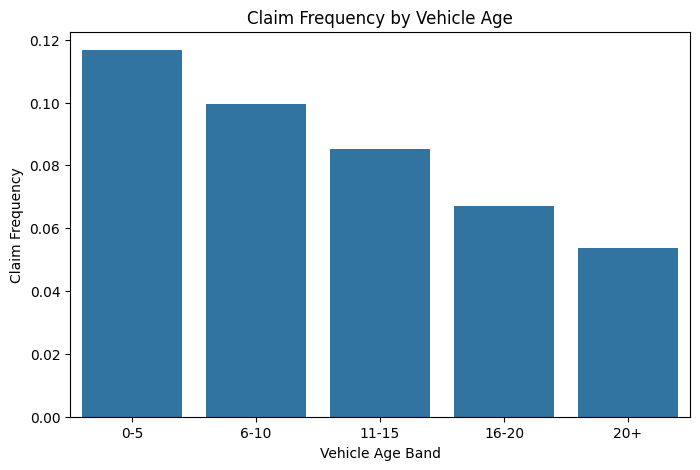

In [45]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=veh_age_risk["VehAgeBand"],
    y=veh_age_risk["Claim_Frequency"]
)

plt.title("Claim Frequency by Vehicle Age")
plt.xlabel("Vehicle Age Band")
plt.ylabel("Claim Frequency")

plt.savefig("../visuals/vehicle_age_risk.png")

plt.show()

### Interpretation

Vehicle age shows variation in claim frequency across different bands, indicating that vehicle characteristics may influence risk levels.

However, these results should be interpreted alongside exposure. Bands with higher total exposure provide more stable and credible estimates of claim frequency, while lower-exposure segments may show more variability.

Overall, vehicle age appears to contribute to differences in claim frequency, though the effect is less pronounced compared to driver age.

## 8. Claim Frequency by Bonus-Malus Band

The Bonus-Malus system is commonly used in motor insurance to adjust premiums based on policyholder claim history.

Drivers with fewer claims receive a bonus (lower premium), while drivers with more claims receive a malus (higher premium).

This section analyses how claim frequency varies across Bonus-Malus levels.

In [15]:
df["BonusMalusBand"] = pd.cut(
    df["BonusMalus"],
    bins=[0,75,100,125,150,np.inf],
    labels=["Low","Moderate","High","Very High","Extreme"],
    include_lowest=True
)

In [49]:
bm_risk = df.groupby("BonusMalusBand", observed=False).agg(
    Total_Claims=("ClaimNb", "sum"),
    Total_Exposure=("Exposure", "sum")
).reset_index()

bm_risk["Claim_Frequency"] = (
    bm_risk["Total_Claims"] / bm_risk["Total_Exposure"]
)

bm_risk

,BonusMalusBand,Total_Claims,Total_Exposure,Claim_Frequency
0,Low,27670,310107.788200,0.089227
1,Moderate,7090,44820.338259,0.158187
2,High,1178,3198.266094,0.368325
3,Very High,110,277.924712,0.395791
4,Extreme,54,95.128197,0.567655


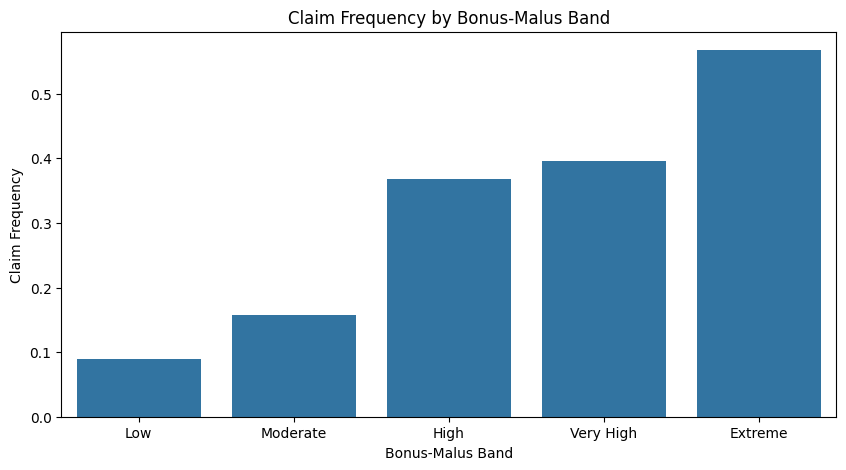

In [53]:
bm_risk = bm_risk.sort_values(by="BonusMalusBand")

plt.figure(figsize=(10,5))

sns.barplot(
    x=bm_risk["BonusMalusBand"],
    y=bm_risk["Claim_Frequency"]
)

plt.title("Claim Frequency by Bonus-Malus Band")
plt.xlabel("Bonus-Malus Band")
plt.ylabel("Claim Frequency")

plt.savefig("../visuals/bonus_malus_risk.png")

plt.show()

### Interpretation

Claim frequency increases consistently with higher Bonus-Malus levels, indicating a clear monotonic relationship between past claims experience and current claim risk.

Policyholders with higher Bonus-Malus values exhibit significantly higher claim frequencies, reflecting the impact of prior claims history on future risk.

This pattern is highly consistent with actuarial expectations, as Bonus-Malus systems are specifically designed to capture and penalize higher-risk policyholders.

Overall, Bonus-Malus emerges as a strong predictor of claim frequency in the portfolio. However, higher bands such as "Very High" and "Extreme" have relatively low exposure, so their estimates may be less stable. Despite this, the overall increasing trend reinforces the importance of Bonus-Malus as a key rating variable in motor insurance pricing.

## 9. Claim Frequency by Vehicle Power

Vehicle power can influence driving behaviour and accident severity. 
Higher-powered vehicles may be associated with higher speeds and more aggressive driving patterns, which could increase accident risk.

This section examines how claim frequency varies across different vehicle power levels.


In [57]:
df["VehPowerBand"] = pd.cut(
    df["VehPower"],
    bins=[0, 5, 7, 9, np.inf],
    labels=["Low", "Moderate", "High", "Very High"],
    include_lowest=True
)

In [58]:
veh_power_risk = df.groupby("VehPowerBand", observed=False).agg(
    Total_Claims=("ClaimNb", "sum"),
    Total_Exposure=("Exposure", "sum")
).reset_index()

veh_power_risk["Claim_Frequency"] = (
    veh_power_risk["Total_Claims"] / veh_power_risk["Total_Exposure"]
)

veh_power_risk

,VehPowerBand,Total_Claims,Total_Exposure,Claim_Frequency
0,Low,12977,128246.986124,0.101188
1,Moderate,16008,160474.666872,0.099754
2,High,3676,38032.829961,0.096653
3,Very High,3441,31744.962505,0.108395


In [59]:
veh_power_risk = veh_power_risk.sort_values(by="VehPowerBand")
veh_power_risk

,VehPowerBand,Total_Claims,Total_Exposure,Claim_Frequency
0,Low,12977,128246.986124,0.101188
1,Moderate,16008,160474.666872,0.099754
2,High,3676,38032.829961,0.096653
3,Very High,3441,31744.962505,0.108395


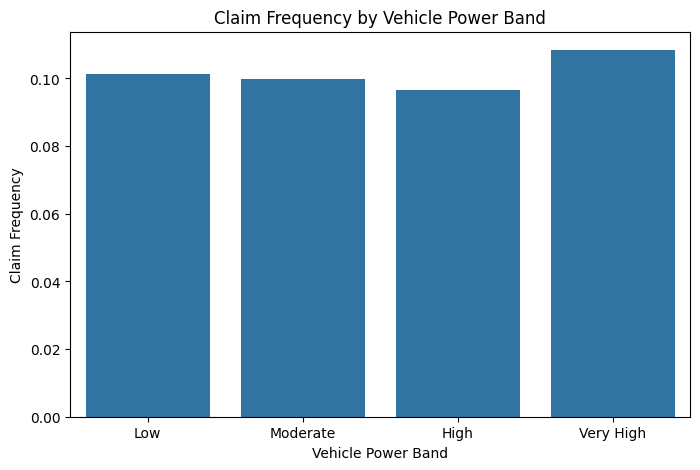

In [60]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=veh_power_risk["VehPowerBand"],
    y=veh_power_risk["Claim_Frequency"]
)

plt.title("Claim Frequency by Vehicle Power Band")
plt.xlabel("Vehicle Power Band")
plt.ylabel("Claim Frequency")

plt.savefig("../visuals/vehicle_power_risk.png")

plt.show()


### Interpretation

Claim frequency varies across vehicle power bands, suggesting that vehicle characteristics may be associated with differences in observed insurance risk.

However, the relationship is less pronounced and less consistently monotonic than for variables such as Bonus-Malus or driver age. This indicates that vehicle power may have some explanatory value, but it is not among the strongest standalone predictors in the portfolio.

As with other segmentation results, these findings should be interpreted alongside exposure, since the credibility of frequency estimates depends on the volume of data within each band.

Overall, vehicle power appears to be a secondary segmentation variable in claim frequency analysis rather than a dominant rating factor.


## 10. Claim Frequency by Population Density

Population density can influence accident risk, as areas with higher traffic volumes may experience more frequent collisions.

This section analyses how claim frequency varies across different population density levels.


In [20]:
df["DensityBand"] = pd.qcut(
    df["Density"],
    q=5,
    labels=["Very Low","Low","Medium","High","Very High"]
)


In [54]:
density_risk = df.groupby("DensityBand", observed=False).agg(
    Total_Claims=("ClaimNb", "sum"),
    Total_Exposure=("Exposure", "sum")
).reset_index()

density_risk["Claim_Frequency"] = (
    density_risk["Total_Claims"] / density_risk["Total_Exposure"]
)

density_risk

,DensityBand,Total_Claims,Total_Exposure,Claim_Frequency
0,Very Low,6753,81409.009565,0.082952
1,Low,6743,74104.379569,0.090993
2,Medium,7091,72041.131585,0.098430
3,High,7855,69486.203925,0.113044
4,Very High,7660,61458.720818,0.124637


In [55]:
density_risk = density_risk.sort_values(by="DensityBand")
density_risk

,DensityBand,Total_Claims,Total_Exposure,Claim_Frequency
0,Very Low,6753,81409.009565,0.082952
1,Low,6743,74104.379569,0.090993
2,Medium,7091,72041.131585,0.098430
3,High,7855,69486.203925,0.113044
4,Very High,7660,61458.720818,0.124637


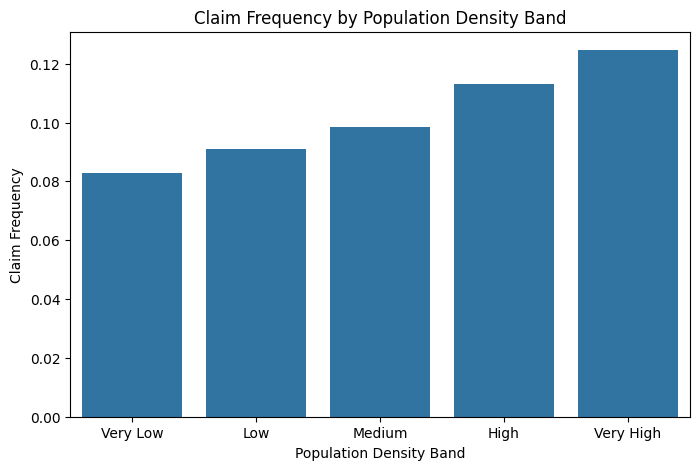

In [56]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=density_risk["DensityBand"],
    y=density_risk["Claim_Frequency"]
)

plt.title("Claim Frequency by Population Density Band")
plt.xlabel("Population Density Band")
plt.ylabel("Claim Frequency")

plt.savefig("../visuals/density_risk.png")

plt.show()


### Interpretation

Claim frequency increases across population density bands, suggesting that geographic environment may influence motor insurance risk.

Higher-density areas exhibit higher claim frequency than lower-density areas, which is consistent with greater traffic congestion, accident exposure, and driving complexity in more urban settings.

These results should still be interpreted alongside exposure, since more credible conclusions come from segments with sufficient portfolio representation.

Overall, population density appears to be a meaningful segmentation variable in claim frequency analysis, although its effect is less direct than variables such as driver age or Bonus-Malus.


## 11. Poisson Regression Model

While segmentation analysis provides useful insights into how individual variables relate to claim frequency, actuarial pricing models typically evaluate multiple risk factors simultaneously.

To estimate the expected claim frequency while accounting for multiple rating variables, a Poisson regression model is fitted.

Poisson models are commonly used in insurance because claim counts represent discrete events that occur over a given exposure period.

In [23]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [24]:
df["DriverAgeBand"] = df["DriverAgeBand"].astype("category")
df["VehAgeBand"] = df["VehAgeBand"].astype("category")
df["BonusMalusBand"] = df["BonusMalusBand"].astype("category")
df["DensityBand"] = df["DensityBand"].astype("category")

In [25]:
df_model = df.copy()

model_vars = [
    "ClaimNb",
    "Exposure",
    "DriverAgeBand",
    "VehAgeBand",
    "BonusMalusBand",
    "DensityBand"
]

df_model = df_model[model_vars].dropna().copy()
df_model = df_model[df_model["Exposure"] > 0].copy()

print("Raw rows:", len(df))
print("Model rows:", len(df_model))
print("Dropped rows:", len(df) - len(df_model))

Raw rows: 678013
Model rows: 678013
Dropped rows: 0


In [26]:
poisson_model = smf.glm(
    formula="ClaimNb ~ DriverAgeBand + VehAgeBand + BonusMalusBand + DensityBand",
    data=df_model,
    family=sm.families.Poisson(),
    offset=np.log(df_model["Exposure"])
).fit()

print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   677996
Model Family:                 Poisson   Df Model:                           16
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4439e+05
Date:                Wed, 18 Mar 2026   Deviance:                   2.1946e+05
Time:                        01:27:30   Pearson chi2:                 1.88e+06
No. Iterations:                     7   Pseudo R-squ. (CS):           0.007378
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

In [61]:
mean_claims = df_model["ClaimNb"].mean()
var_claims = df_model["ClaimNb"].var()

print("Mean of ClaimNb:", mean_claims)
print("Variance of ClaimNb:", var_claims)
print("Variance / Mean:", var_claims / mean_claims)

Mean of ClaimNb: 0.05324676665491664
Variance of ClaimNb: 0.057656332380878514
Variance / Mean: 1.0828137744877455


### Overdispersion Check

For a Poisson model, the variance of the response variable should be approximately equal to its mean.

If the variance significantly exceeds the mean, this indicates overdispersion, suggesting that a Poisson model may not be fully appropriate and that alternative models (such as Negative Binomial) could provide a better fit.

The variance-to-mean ratio is close to 1, suggesting that overdispersion is not severe and that the Poisson model is reasonably appropriate for this dataset.

In [62]:
import numpy as np
import pandas as pd

coef = poisson_model.params
conf = poisson_model.conf_int()

coef_table = pd.DataFrame({
    "Variable": coef.index.str.replace("T.", "", regex=False),
    "Coefficient": coef.values,
    "Rate_Ratio": np.exp(coef.values),
    "CI_Lower": np.exp(conf[0].values),
    "CI_Upper": np.exp(conf[1].values)
})

coef_table

,Variable,Coefficient,Rate_Ratio,CI_Lower,CI_Upper
0,Intercept,-2.321741,0.098103,0.093188,0.103277
1,DriverAgeBand[26-35],-0.242421,0.784726,0.749255,0.821876
2,DriverAgeBand[36-50],-0.036626,0.964037,0.920323,1.009828
3,DriverAgeBand[51-70],-0.059071,0.942640,0.898505,0.988942
4,DriverAgeBand[70+],-0.006543,0.993478,0.936850,1.053529
5,VehAgeBand[6-10],-0.168772,0.844701,0.824040,0.865881
6,VehAgeBand[11-15],-0.334253,0.715873,0.695852,0.736469
7,VehAgeBand[16-20],-0.571507,0.564674,0.537076,0.593690
8,VehAgeBand[20+],-0.731072,0.481393,0.427387,0.542223
9,BonusMalusBand[Moderate],0.596566,1.815872,1.760825,1.872640


Confidence Intervals

The table also reports 95% confidence intervals for the estimated rate ratios.
These intervals provide a measure of statistical uncertainty around the estimated effects.
If the interval does not include 1, the corresponding variable has a statistically significant impact on claim frequency at the 5% level.

### Reference Categories

The model uses the following baseline (reference) categories:

- Driver Age: 18–25  
- Vehicle Age: 0–5 years  
- Bonus-Malus: Low  
- Population Density: Very Low  

All coefficients and rate ratios are interpreted relative to these baseline groups.

### Rate Ratio Interpretation

For a Poisson regression model with a log link, the coefficients represent changes in the log of the expected claim frequency.

Exponentiating the coefficients produces **rate ratios**, which indicate how the expected claim frequency changes relative to the reference category.

A rate ratio greater than 1 implies a higher expected claim frequency relative to the baseline group, while a value below 1 implies a lower expected frequency.

### Model Interpretation

The Poisson regression model estimates the expected claim frequency while accounting for multiple rating variables simultaneously.

Driver age shows meaningful differences in claim frequency relative to the reference category (18–25). Drivers aged 26–35 exhibit approximately 22% lower claim frequency, while older age groups display slightly lower or similar frequencies relative to the baseline.

Vehicle age has a clear negative relationship with claim frequency. Compared to newer vehicles, older vehicles are associated with progressively lower claim frequencies. This may reflect lower vehicle usage, reduced driving intensity, or behavioural differences among policyholders.

Bonus–malus level shows the strongest relationship with claim frequency. Policies with higher bonus–malus levels exhibit substantially higher expected claim frequencies, reflecting the predictive power of past claims experience in insurance pricing.

Population density also demonstrates a positive association with claim frequency. Policies located in more densely populated areas tend to experience higher accident risk due to increased traffic exposure.

Overall, the model confirms several key risk factors commonly used in motor insurance pricing and demonstrates how multiple rating variables can be combined within a generalized linear modelling framework to estimate expected claim frequency.

The pseudo R-squared value is relatively low, which is common in insurance frequency modelling due to the inherent randomness of claim occurrences. While the model captures statistically significant relationships, much of the variation in claim frequency remains unexplained, indicating that additional variables or more advanced modelling techniques could further improve predictive performance.

These results align with actuarial expectations, particularly the strong impact of Bonus-Malus, reinforcing its importance as a key rating variable in motor insurance pricing.

## 12. Overdispersion Test

The dispersion statistic was calculated to assess whether the Poisson model adequately captures the variability in claim counts.

A value close to 1 supports the Poisson assumption, while a value materially greater than 1 indicates overdispersion and suggests that a more flexible model may be needed.

In [28]:
# Pearson Chi-square dispersion statistic
pearson_chi2 = poisson_model.pearson_chi2
df_resid = poisson_model.df_resid

dispersion = pearson_chi2 / df_resid

print("Pearson Chi-square:", pearson_chi2)
print("Residual DF:", df_resid)
print("Dispersion Statistic:", dispersion)

Pearson Chi-square: 1876736.798299781
Residual DF: 677996
Dispersion Statistic: 2.7680647058386496


### Interpretation

The dispersion statistic is 2.77, which is materially greater than 1 and indicates the presence of overdispersion.

This suggests that the Poisson model understates the variability in claim counts, making the Negative Binomial model a more appropriate alternative for the next stage of analysis.

## 13. Negative Binomial Regression Model

The overdispersion test indicated that the variance of the claim counts exceeds the mean, violating the key assumption of the Poisson model.

In such cases, the Negative Binomial regression model is often used as an alternative, as it introduces a dispersion parameter that allows the variance to exceed the mean (Var > Mean)

Given the evidence of overdispersion (dispersion ≈ 2.77), the Negative Binomial model is expected to provide a better fit than the Poisson model.

To account for the observed overdispersion in the claim data, a Negative Binomial regression model is fitted using the same set of explanatory variables as in the Poisson model.

This allows for a comparison between the two models and provides a more flexible framework for modelling claim frequency in insurance portfolios.

In [64]:
# Fit Negative Binomial model
nb_model = smf.glm(
    formula="ClaimNb ~ DriverAgeBand + VehAgeBand + BonusMalusBand + DensityBand",
    data=df_model,
    family=sm.families.NegativeBinomial(),
    offset=np.log(df_model["Exposure"])
).fit()

print(nb_model.summary())

c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\genmod\families\family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


                 Generalized Linear Model Regression Results                  
Dep. Variable:                ClaimNb   No. Observations:               678013
Model:                            GLM   Df Residuals:                   677996
Model Family:        NegativeBinomial   Df Model:                           16
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.4394e+05
Date:                Wed, 18 Mar 2026   Deviance:                   1.9138e+05
Time:                        17:13:58   Pearson chi2:                 1.82e+06
No. Iterations:                     7   Pseudo R-squ. (CS):           0.006871
Covariance Type:            nonrobust                                         
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

Note: The GLM implementation of the Negative Binomial model does not explicitly estimate the dispersion parameter (alpha). More advanced implementations can estimate this parameter directly for improved model accuracy.

The coefficient signs and relative magnitudes are broadly consistent with the Poisson model, indicating stable relationships across model specifications.

To formally assess which model provides a better fit, the Poisson and Negative Binomial models are compared using information criteria such as AIC, where lower values indicate a better model fit.

## 14. Model Comparison

In [30]:
print("Poisson AIC:", poisson_model.aic)
print("Negative Binomial AIC:", nb_model.aic)

Poisson AIC: 288817.47681298584
Negative Binomial AIC: 287906.8006408301


The Negative Binomial model reduces AIC by approximately 910 points compared to the Poisson model, indicating a substantially better fit.

### Model Comparison

To evaluate which model provides a better fit to the data, the Akaike Information Criterion (AIC) is compared between the Poisson and Negative Binomial models.

A lower AIC value indicates a better trade-off between goodness of fit and model complexity, penalizing models that overfit.

If the Negative Binomial model produces a lower AIC than the Poisson model, this suggests that it provides a better fit to the claim data, likely due to its ability to account for overdispersion.


### Interpretation

The Negative Binomial model produces a lower AIC value than the Poisson model, indicating a superior fit to the claim frequency data.

This result is consistent with the earlier overdispersion test, which showed that the variance of claim counts exceeds the mean, violating the Poisson model assumption.

By introducing an additional dispersion parameter, the Negative Binomial model is able to better accommodate the variability observed in insurance claim data.

Therefore, the Negative Binomial model is preferred over the Poisson model for modelling claim frequency in this dataset.

The large difference in AIC further confirms that accounting for overdispersion is essential for accurate modelling of insurance claim data.

## 15. Model Validation: Observed vs Predicted Claim Frequency

After fitting the final Negative Binomial model, it is important to evaluate how well the model reproduces the observed claim experience.

Model validation is performed by comparing observed claim frequency with model-predicted frequency across risk segments.

If the model is well specified, the predicted values should align closely with the observed values across different risk segments.

In [31]:
df_model["Predicted_Claims"] = poisson_model.predict(
    df_model,
    offset=np.log(df_model["Exposure"])
)

validation = df_model.groupby(
    ["DriverAgeBand", "VehAgeBand", "BonusMalusBand"]
).agg(
    Observed_Claims=("ClaimNb", "sum"),
    Predicted_Claims=("Predicted_Claims", "sum"),
    Exposure=("Exposure", "sum")
)

validation["Observed_Frequency"] = (
    validation["Observed_Claims"] / validation["Exposure"]
)

validation["Predicted_Frequency"] = (
    validation["Predicted_Claims"] / validation["Exposure"]
)

validation

Observed_Claims  Predicted_Claims  \
DriverAgeBand VehAgeBand BonusMalusBand                                      
18-25         0-5        Low                         101        121.558722   
                         Moderate                    689        786.347941   
                         High                        129        170.558103   
                         Very High                     6         12.883490   
                         Extreme                       8          5.753731   
...                                                  ...               ...   
70+           16-20      High                          0          0.084038   
                         Very High                     0          0.078062   
              20+        Low                          40         34.326616   
                         Moderate                      1          0.513680   
                         High                          2          0.776125   

                                            Exposure  Observed_Frequency  \
DriverAgeBand VehAgeBand BonusMalusBand                                    
18-25         0-5        Low             1088.522309            0.092786   
                         Moderate        3802.761603            0.181184   
                         High             364.014757            0.354381   
                         Very High         25.912740            0.231546   
                         Extreme            7.760000            1.030928   
...                                              ...                 ...   
70+           16-20      High               0.370000            0.000000   
                         Very High          0.320000            0.000000   
              20+        Low              668.556393            0.059830   
                         Moderate           5.060000            0.197628   
                         High               3.210000            0.623053   

                                         Predicted_Frequency  
DriverAgeBand VehAgeBand BonusMalusBand                       
18-25         0-5        Low                        0.111673  
                         Moderate                   0.206783  
                         High                       0.468547  
                         Very High                  0.497187  
                         Extreme                    0.741460  
...                                                      ...  
70+           16-20      High                       0.227129  
                         Very High                  0.243943  
              20+        Low                        0.051344  
                         Moderate                   0.101518  
                         High                       0.241783  

[118 rows x 5 columns]

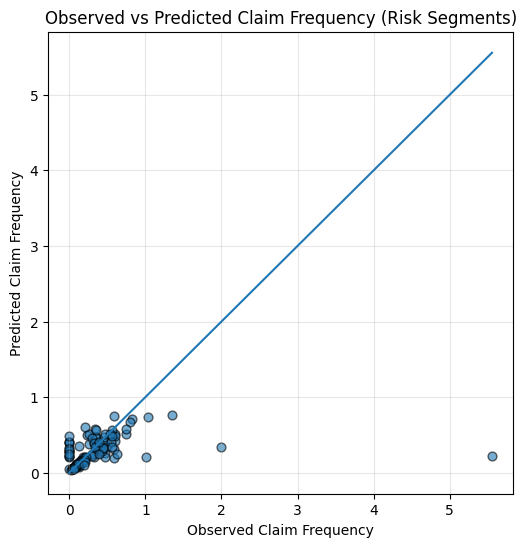

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    validation["Observed_Frequency"],
    validation["Predicted_Frequency"],
    alpha=0.6,
    s=40,
    edgecolor="k"
)
plt.grid(alpha=0.3)

min_val = min(validation["Observed_Frequency"].min(), validation["Predicted_Frequency"].min())
max_val = max(validation["Observed_Frequency"].max(), validation["Predicted_Frequency"].max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("Observed Claim Frequency")
plt.ylabel("Predicted Claim Frequency")
plt.title("Observed vs Predicted Claim Frequency (Risk Segments)")

plt.show()

Most points lie close to the 45-degree line, indicating good overall calibration, although some dispersion is observed in higher-frequency segments.

In [33]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        validation["Observed_Frequency"],
        validation["Predicted_Frequency"]
    )
)

print("RMSE (Observed vs Predicted Frequency):", round(rmse, 4))

RMSE (Observed vs Predicted Frequency): 0.5457


### RMSE Interpretation

The root mean squared error (RMSE) summarises the average magnitude of deviation between observed and predicted claim frequencies across the validation segments.

Lower RMSE values indicate that the fitted model reproduces observed claim frequency more closely across risk segments.

An RMSE of approximately 0.55 suggests moderate prediction error, which is reasonable given the inherent variability in claim frequency data.

In [34]:
bonus_validation = df_model.groupby("BonusMalusBand").agg(
    Observed_Claims=("ClaimNb", "sum"),
    Predicted_Claims=("Predicted_Claims", "sum"),
    Exposure=("Exposure", "sum")
)

bonus_validation["Observed_Frequency"] = (
    bonus_validation["Observed_Claims"] / bonus_validation["Exposure"]
)

bonus_validation["Predicted_Frequency"] = (
    bonus_validation["Predicted_Claims"] / bonus_validation["Exposure"]
)

bonus_validation

,Observed_Claims,Predicted_Claims,Exposure,Observed_Frequency,Predicted_Frequency
BonusMalusBand,,,,,
Low,27670,27670.0,310107.788200,0.089227,0.089227
Moderate,7090,7090.0,44820.338259,0.158187,0.158187
High,1178,1178.0,3198.266094,0.368325,0.368325
Very High,110,110.0,277.924712,0.395791,0.395791
Extreme,54,54.0,95.128197,0.567655,0.567655


In [35]:
performance_summary = {
    "Metric": [
        "Poisson AIC",
        "Negative Binomial AIC",
        "RMSE (Observed vs Predicted Frequency)"
    ],
    "Value": [
        poisson_model.aic,
        nb_model.aic,
        rmse
    ]
}

import pandas as pd
performance_summary = pd.DataFrame(performance_summary)

performance_summary

,Metric,Value
0,Poisson AIC,288817.476813
1,Negative Binomial AIC,287906.800641
2,RMSE (Observed vs Predicted Frequency),0.545704


### Model Performance Summary

The comparison of model performance metrics confirms that the Negative Binomial specification provides a better fit to the data.

The lower AIC value indicates improved balance between model fit and complexity, while the RMSE summarises the average deviation between observed and predicted claim frequencies across risk segments.


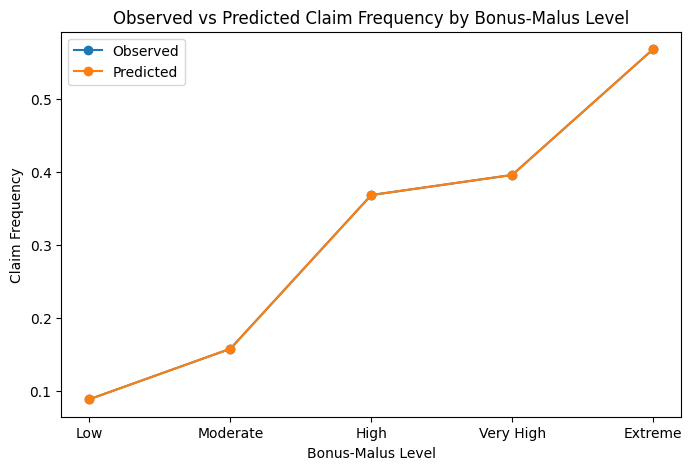

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    bonus_validation.index,
    bonus_validation["Observed_Frequency"],
    marker="o",
    label="Observed"
)

plt.plot(
    bonus_validation.index,
    bonus_validation["Predicted_Frequency"],
    marker="o",
    label="Predicted"
)

plt.xlabel("Bonus-Malus Level")
plt.ylabel("Claim Frequency")
plt.title("Observed vs Predicted Claim Frequency by Bonus-Malus Level")

plt.legend()
plt.show()

### Calibration by Bonus-Malus Level

The comparison of observed and predicted claim frequencies across bonus-malus levels provides an additional check of model calibration.

A well-calibrated model should reproduce the monotonic increase in claim frequency across higher bonus-malus categories, reflecting the predictive value of historical claims experience.

The model successfully captures the increasing trend in claim frequency across bonus-malus levels, indicating strong calibration with respect to prior claims experience.

### Interpretation

The scatter plot compares observed claim frequency with the frequencies predicted by the fitted count regression model across multiple risk segments defined by combinations of rating variables.

If the model fits the data well, the points should lie close to the 45-degree line, indicating that predicted frequencies closely match observed frequencies across segments.

Small deviations from the diagonal are expected due to natural variability in claims data. Overall, the clustering of points around the diagonal suggests that the model provides a reasonable approximation of the underlying claim frequency structure.

### Conclusion

Motor insurance claim frequency was modelled using generalized linear models incorporating key rating variables including driver age, vehicle age, bonus–malus level, and population density. Due to the presence of overdispersion in the claim counts, a Negative Binomial regression model was adopted as the final specification.

The results highlight the strong predictive power of historical claims experience (bonus–malus level), while also confirming meaningful effects from driver demographics, vehicle characteristics, and geographic exposure.

Overall, the analysis demonstrates that the Negative Binomial model provides a robust and well-calibrated framework for modelling claim frequency in motor insurance. By accounting for overdispersion and incorporating key risk factors, the model achieves a strong balance between statistical fit and practical interpretability, making it suitable for actuarial pricing applications.


This approach illustrates how statistical modelling techniques can be effectively applied to real-world insurance data to support risk-based pricing decisions.